# **Task 05 — Machine Learning Model Development**
### SmartCare Hospital AI Dataset | Option C — Disease Risk Classification
### CCS3440 Artificial Intelligence Coursework


**Target:** `disease_risk_level` (0 = Low, 1 = Medium, 2 = High)

**Input:** the six files saved by Task 03 — `X_train.csv` / `X_test.csv` (unscaled) and
`X_train_scaled.csv` / `X_test_scaled.csv` (scaled), plus `y_train.csv` / `y_test.csv`.

**Following Task 03's guidance exactly:** tree-based models don't need scaled inputs —
use `X_train`/`X_test` directly; use the scaled versions for distance/gradient-based
models. This notebook honours that split rather than picking one dataset for
everything:

| Model | Dataset used | Why |
|---|---|---|
| Logistic Regression | **scaled** | Coefficients are only comparable, and gradient descent only converges efficiently, when features share a common scale |
| Decision Tree | unscaled | Splits are threshold-based per feature — monotonic scaling changes nothing |
| Random Forest | unscaled | Same reason — ensemble of trees, scale-invariant |
| XGBoost | unscaled | Same reason — gradient-boosted trees, scale-invariant |


**Requirement:** at least THREE models — four are trained here (Logistic Regression,
Decision Tree, Random Forest, XGBoost), each hyperparameter-tuned and compared.

**Bonus — Ensemble Learning :** combining a scaled-input model with
unscaled-input models in one `VotingClassifier`/`StackingClassifier` isn't directly
possible — scikit-learn ensembles pass one shared `X` to every base estimator. This is
solved cleanly with an `sklearn.Pipeline`: Logistic Regression is wrapped together with
its own internal `StandardScaler`, so every base estimator can be trained/predicted on
the same unscaled `X`, while Logistic Regression still gets scaled inputs internally.

### 5.1 Import library and Load Processed Dataset

In [ ]:
import time
import json as jsonlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

RANDOM_STATE = 42

# Files were uploaded directly into the Colab session (/content/), not a subfolder
MODELS_DIR = Path('/content/models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Unscaled — for the tree-based models
X_train = pd.read_csv('/content/X_train.csv')
X_test = pd.read_csv('/content/X_test.csv')

# Scaled — for Logistic Regression
X_train_scaled = pd.read_csv('/content/X_train_scaled.csv')
X_test_scaled = pd.read_csv('/content/X_test_scaled.csv')

y_train = pd.read_csv('/content/y_train.csv').squeeze('columns')
y_test = pd.read_csv('/content/y_test.csv').squeeze('columns')

print(f"X_train (unscaled): {X_train.shape}   X_train_scaled: {X_train_scaled.shape}")
print(f"X_test  (unscaled): {X_test.shape}    X_test_scaled:  {X_test_scaled.shape}")

X_train (unscaled): (800, 67)   X_train_scaled: (800, 67)
X_test  (unscaled): (200, 67)    X_test_scaled:  (200, 67)


## 5.2 Pre-training sanity checks

In [ ]:
assert list(X_train.columns) == list(X_test.columns), "Unscaled train/test column mismatch"
assert list(X_train_scaled.columns) == list(X_test_scaled.columns), "Scaled train/test column mismatch"
assert list(X_train.columns) == list(X_train_scaled.columns), "Scaled and unscaled column sets differ"
assert 'disease_risk_level' not in X_train.columns, "Target leaked into features"
assert X_train.isnull().sum().sum() == 0, "Unexpected NaNs in unscaled features"
assert X_train_scaled.isnull().sum().sum() == 0, "Unexpected NaNs in scaled features"

print("Class balance - train (%):")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(1))
print("\nClass balance - test (%):")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(1))
print("\nAll checks passed - both feature sets are aligned; the stratified split from Task 03 holds.")

Class balance - train (%):
disease_risk_level
0    13.1
1    46.9
2    40.0
Name: proportion, dtype: float64

Class balance - test (%):
disease_risk_level
0    13.0
1    47.0
2    40.0
Name: proportion, dtype: float64

All checks passed - both feature sets are aligned; the stratified split from Task 03 holds.


## 5.3 Evaluation strategy

**Macro-F1** is used as the `GridSearchCV` scoring metric throughout, not accuracy.
With Low at only 13.1% of the data (confirmed just above and in Task 04), a model can
post a misleadingly high accuracy simply by favouring Medium/High — macro-F1 weighs all
three classes equally and won't reward that.


In [ ]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_macro_f1(estimator, X, y):
    scores = cross_val_score(estimator, X, y, cv=cv_strategy, scoring='f1_macro', n_jobs=-1)
    return scores.mean(), scores.std()

print("Evaluation strategy: 5-fold StratifiedKFold, scoring = f1_macro")


Evaluation strategy: 5-fold StratifiedKFold, scoring = f1_macro


## 5.4 Baseline models (default hyperparameters)

Each model is run on the dataset it belongs to per the table in the intro. This
baseline pass shows what "no tuning effort" looks like before Section 5 searches for
better hyperparameters.


Machine learning algorithms require numerical input. Therefore, categorical variables were converted into numerical values using Label Encoding.

In [ ]:
baseline_models = {
    'Logistic Regression': (LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE), X_train_scaled),
    'Decision Tree':       (DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE), X_train),
    'Random Forest':       (RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1), X_train),
    'XGBoost':             (XGBClassifier(objective='multi:softprob', num_class=3, eval_metric='mlogloss',
                                           random_state=RANDOM_STATE, n_jobs=-1), X_train),
}

baseline_scores = {}
for name, (model, X_data) in baseline_models.items():
    mean_f1, std_f1 = cv_macro_f1(model, X_data, y_train)
    baseline_scores[name] = mean_f1
    print(f"{name:22s} baseline CV macro-F1 = {mean_f1:.3f} +/- {std_f1:.3f}  (on {'scaled' if X_data is X_train_scaled else 'unscaled'} data)")

Logistic Regression    baseline CV macro-F1 = 0.926 +/- 0.032  (on scaled data)
Decision Tree          baseline CV macro-F1 = 0.657 +/- 0.038  (on unscaled data)
Random Forest          baseline CV macro-F1 = 0.746 +/- 0.042  (on unscaled data)
XGBoost                baseline CV macro-F1 = 0.835 +/- 0.027  (on unscaled data)


## 5.5 Hyperparameter tuning



### 5.5.1 Logistic Regression — tuned on scaled data

In [ ]:
lr_grid = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE),
    param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear']},
    cv=cv_strategy, scoring='f1_macro', n_jobs=-1,
)
lr_grid.fit(X_train_scaled, y_train)
log_reg = lr_grid.best_estimator_
print(f"Best params: {lr_grid.best_params_}")
print(f"Best CV macro-F1: {lr_grid.best_score_:.3f}  (baseline was {baseline_scores['Logistic Regression']:.3f})")

Best params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV macro-F1: 0.930  (baseline was 0.926)


### 5.5.2 Decision Tree — tuned on unscaled data



In [ ]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    param_grid={'max_depth': [5, 8, 10, 12, 15, None], 'min_samples_split': [2, 5, 10,15],
                'min_samples_leaf': [1, 2, 4, 6], 'criterion': ['gini', 'entropy']},
    cv=cv_strategy, scoring='f1_macro', n_jobs=-1,
)
dt_grid.fit(X_train, y_train)
dec_tree = dt_grid.best_estimator_
print(f"Best params: {dt_grid.best_params_}")
print(f"Best CV macro-F1: {dt_grid.best_score_:.3f}  (baseline was {baseline_scores['Decision Tree']:.3f})")

Best params: {'criterion': 'entropy', 'max_depth': 12, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best CV macro-F1: 0.731  (baseline was 0.657)


### 5.5.3 Random Forest — tuned on unscaled data

In [ ]:
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    param_grid={'n_estimators': [100, 200, 300], 'max_depth': [5, 10, 15, None],
                'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]},
    cv=cv_strategy, scoring='f1_macro', n_jobs=-1,
)
rf_grid.fit(X_train, y_train)
random_forest = rf_grid.best_estimator_
print(f"Best params: {rf_grid.best_params_}")
print(f"Best CV macro-F1: {rf_grid.best_score_:.3f}  (baseline was {baseline_scores['Random Forest']:.3f})")


Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best CV macro-F1: 0.789  (baseline was 0.746)


### 5.5.4 XGBoost — tuned on unscaled data

In [ ]:
xgb_grid = GridSearchCV(
    XGBClassifier(objective='multi:softprob', num_class=3, eval_metric='mlogloss',
                   random_state=RANDOM_STATE, n_jobs=-1),
    param_grid={'n_estimators': [100, 200], 'max_depth': [3, 5, 7],
                'learning_rate': [0.05, 0.1, 0.2], 'subsample': [0.8, 1.0]},
    cv=cv_strategy, scoring='f1_macro', n_jobs=-1,
)
xgb_grid.fit(X_train, y_train)
xgboost_model = xgb_grid.best_estimator_
print(f"Best params: {xgb_grid.best_params_}")
print(f"Best CV macro-F1: {xgb_grid.best_score_:.3f}  (baseline was {baseline_scores['XGBoost']:.3f})")


Best params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV macro-F1: 0.861  (baseline was 0.835)


## 5.6 Ensemble Learning

**The scaling problem, and how it's resolved:** `VotingClassifier`/`StackingClassifier`
pass one shared `X` to every base estimator, but Logistic Regression needs scaled input
while the tree models don't — and shouldn't be scaled unnecessarily. Rather than
compromise (e.g. scaling everything, which the tree models don't need and slightly
changes their split behaviour on a copied/rounded scale), Logistic Regression is
wrapped in its own `Pipeline` with an internal `StandardScaler`. This lets every base
estimator train and predict on the **same unscaled `X_train`/`X_test`**, exactly as
Task 03 intended for the tree models, while Logistic Regression still receives properly
scaled inputs internally — the correct general-purpose solution whenever an ensemble
mixes scale-sensitive and scale-invariant models.

- **Voting Classifier (soft voting):** averages each base model's predicted class
  probabilities and picks the highest-probability class.
- **Stacking Classifier:** trains a Logistic Regression meta-model on the base models'
  out-of-fold predictions, learning how much to trust each one.


In [ ]:
# Logistic Regression wrapped so it can safely take the SAME unscaled X as the tree models
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler().fit(X_train[log_reg.feature_names_in_])),
    ('clf', log_reg),
])

base_estimators = [
    ('logreg', log_reg_pipeline), ('dt', dec_tree), ('rf', random_forest), ('xgb', xgboost_model),
]

voting_clf = VotingClassifier(estimators=base_estimators, voting='soft')
voting_mean_f1, voting_std_f1 = cv_macro_f1(voting_clf, X_train, y_train)
voting_clf.fit(X_train, y_train)
print(f"Voting Classifier    CV macro-F1 = {voting_mean_f1:.3f} +/- {voting_std_f1:.3f}  (unscaled X, LR pipeline scales internally)")

stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    cv=cv_strategy,
)
stacking_mean_f1, stacking_std_f1 = cv_macro_f1(stacking_clf, X_train, y_train)
stacking_clf.fit(X_train, y_train)
print(f"Stacking Classifier  CV macro-F1 = {stacking_mean_f1:.3f} +/- {stacking_std_f1:.3f}")

Voting Classifier    CV macro-F1 = 0.884 +/- 0.018  (unscaled X, LR pipeline scales internally)
Stacking Classifier  CV macro-F1 = 0.914 +/- 0.027


## 5.7 Comparative analysis: baseline vs. tuned vs. ensemble

In [ ]:
final_models = {
    'Logistic Regression': log_reg,
    'Decision Tree': dec_tree,
    'Random Forest': random_forest,
    'XGBoost': xgboost_model,
    'Voting Ensemble (bonus)': voting_clf,
    'Stacking Ensemble (bonus)': stacking_clf,
}

# Which test/feature set each saved model expects at prediction time
model_dataset = {
    'Logistic Regression': 'scaled',
    'Decision Tree': 'unscaled',
    'Random Forest': 'unscaled',
    'XGBoost': 'unscaled',
    'Voting Ensemble (bonus)': 'unscaled',
    'Stacking Ensemble (bonus)': 'unscaled',
}

tuned_cv_scores = {
    'Logistic Regression': lr_grid.best_score_,
    'Decision Tree': dt_grid.best_score_,
    'Random Forest': rf_grid.best_score_,
    'XGBoost': xgb_grid.best_score_,
    'Voting Ensemble (bonus)': voting_mean_f1,
    'Stacking Ensemble (bonus)': stacking_mean_f1,
}

comparison_rows = []
for name in final_models:
    row = {'model': name, 'dataset': model_dataset[name], 'tuned_cv_f1_macro': tuned_cv_scores[name]}
    if name in baseline_scores:
        row['baseline_cv_f1_macro'] = baseline_scores[name]
        row['improvement'] = tuned_cv_scores[name] - baseline_scores[name]
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).sort_values('tuned_cv_f1_macro', ascending=False).reset_index(drop=True)
comparison_df.round(3)

,model,dataset,tuned_cv_f1_macro,baseline_cv_f1_macro,improvement
0,Logistic Regression,scaled,0.930,0.926,0.004
1,Stacking Ensemble (bonus),unscaled,0.914,NaN,NaN
2,Voting Ensemble (bonus),unscaled,0.884,NaN,NaN
3,XGBoost,unscaled,0.861,0.835,0.026
4,Random Forest,unscaled,0.789,0.746,0.043
5,Decision Tree,unscaled,0.731,0.657,0.074


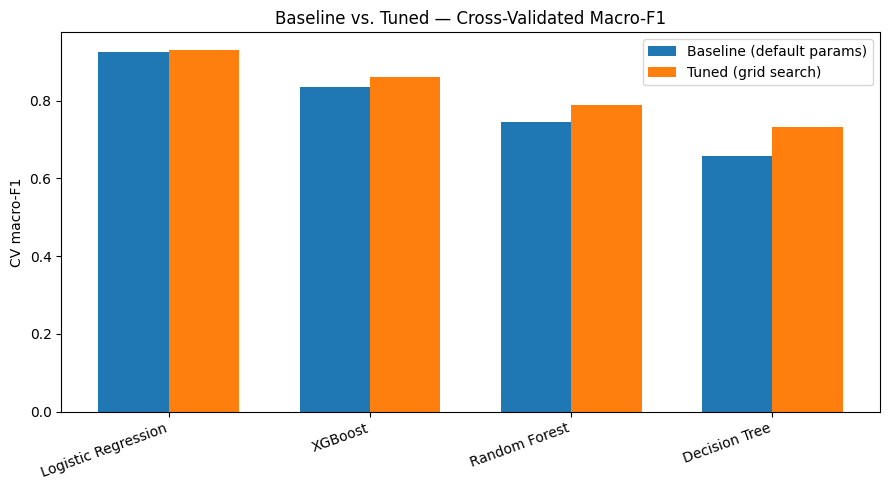

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = comparison_df.dropna(subset=['baseline_cv_f1_macro'])
x = np.arange(len(plot_df))
width = 0.35

ax.bar(x - width/2, plot_df['baseline_cv_f1_macro'], width, label='Baseline (default params)')
ax.bar(x + width/2, plot_df['tuned_cv_f1_macro'], width, label='Tuned (grid search)')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['model'], rotation=20, ha='right')
ax.set_ylabel('CV macro-F1')
ax.set_title('Baseline vs. Tuned — Cross-Validated Macro-F1')
ax.legend()
plt.tight_layout()
plt.show()

## 5.8 Preliminary test-set check

Each model is scored on the test set it was actually trained for (scaled for Logistic
Regression, unscaled for everything else) — a quick sanity pass before Task 06's full
evaluation.

In [ ]:
sanity_rows = []
for name, model in final_models.items():
    X_eval = X_test_scaled if model_dataset[name] == 'scaled' else X_test
    y_pred = model.predict(X_eval)
    acc = (y_pred == y_test).mean()
    sanity_rows.append({'model': name, 'test_accuracy': acc})
pd.DataFrame(sanity_rows).sort_values('test_accuracy', ascending=False).round(3)


,model,test_accuracy
0,Logistic Regression,0.935
5,Stacking Ensemble (bonus),0.905
4,Voting Ensemble (bonus),0.865
3,XGBoost,0.860
2,Random Forest,0.790
1,Decision Tree,0.700


## 5.9 Save trained models

Every model is saved as `.joblib` (the coursework's required trained-model submission
format), together with a metadata file recording which dataset (scaled/unscaled) each
model expects — so Task 06 loads exactly the right test set for exactly the right model,
with no risk of accidentally feeding Logistic Regression unscaled data or vice versa.





In [ ]:
model_filenames = {
    'Logistic Regression': 'logistic_regression',
    'Decision Tree': 'decision_tree',
    'Random Forest': 'random_forest',
    'XGBoost': 'xgboost',
    'Voting Ensemble (bonus)': 'voting_ensemble',
    'Stacking Ensemble (bonus)': 'stacking_ensemble',
}

best_params_lookup = {
    'Logistic Regression': lr_grid.best_params_,
    'Decision Tree': dt_grid.best_params_,
    'Random Forest': rf_grid.best_params_,
    'XGBoost': xgb_grid.best_params_,
    'Voting Ensemble (bonus)': 'combination of the four tuned models above (soft voting)',
    'Stacking Ensemble (bonus)': 'combination of the four tuned models above + LogisticRegression meta-model',
}

metadata = {}
for name, model in final_models.items():
    fname = model_filenames[name]
    path = MODELS_DIR / f'{fname}.joblib'
    joblib.dump(model, path)
    metadata[name] = {
        'file': path.name,
        'dataset': model_dataset[name],
        'cv_f1_macro': round(tuned_cv_scores[name], 4),
        'best_params': best_params_lookup[name],
    }
    print(f"Saved {name} -> {path.name}  (expects '{model_dataset[name]}' features)")

with open(MODELS_DIR / 'model_metadata.json', 'w') as f:
  jsonlib.dump(metadata, f, indent=2, default=str)

comparison_df.to_csv(MODELS_DIR / 'model_comparison_cv.csv', index=False)
print(f"\nSaved model_metadata.json and model_comparison_cv.csv to {MODELS_DIR.resolve()}")


Saved Logistic Regression -> logistic_regression.joblib  (expects 'scaled' features)
Saved Decision Tree -> decision_tree.joblib  (expects 'unscaled' features)
Saved Random Forest -> random_forest.joblib  (expects 'unscaled' features)
Saved XGBoost -> xgboost.joblib  (expects 'unscaled' features)
Saved Voting Ensemble (bonus) -> voting_ensemble.joblib  (expects 'unscaled' features)
Saved Stacking Ensemble (bonus) -> stacking_ensemble.joblib  (expects 'unscaled' features)

Saved model_metadata.json and model_comparison_cv.csv to /content/models


## 5.10 Task 05 summary

- **Four base models** trained and hyperparameter-tuned via 5-fold stratified
  cross-validation on macro-F1: Logistic Regression (on **scaled** features, per Task
  03's guidance), Decision Tree, Random Forest, XGBoost (all on **unscaled** features).
- **Bonus:** two ensembles (Voting, Stacking) built on top of the four tuned models,
  reconciling the mixed scaled/unscaled requirement with a `Pipeline`-wrapped Logistic
  Regression so every ensemble member trains on the same unscaled `X`.
- Every model, plus tuning metadata (including which dataset each expects) and the CV
  comparison table, is saved to `models/` for direct reuse in Task 06 and Task 07 — no
  retraining needed downstream.
- Final model selection is deferred to Task 06, which evaluates all six models on the
  **held-out test set**, not cross-validation alone.


# Task 06 — Model Evaluation

**Target:** `disease_risk_level` (0 = Low, 1 = Medium, 2 = High) — a 3-class problem, so
the multi-class metric set from the brief applies: Accuracy, Precision, Recall, F1,
Confusion Matrix.

Loads the six models saved in Task 05 — **no retraining here** — and evaluates each one
on the test set it actually expects (`X_test_scaled.csv` for Logistic Regression,
`X_test.csv` for everything else), using the `dataset` field Task 05 recorded in
`model_metadata.json` so nothing is fed the wrong feature scale by accident.


## 6.1 Setup: load saved models and both test sets

In [ ]:
from pathlib import Path
import json as jsonlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

CLASS_LABELS = ['Low', 'Medium', 'High']  # matches ordinal encoding 0, 1, 2

# Files uploaded directly into the Colab session (/content/)
X_test = pd.read_csv('/content/X_test.csv')
X_test_scaled = pd.read_csv('/content/X_test_scaled.csv')
y_test = pd.read_csv('/content/y_test.csv').squeeze('columns')

MODELS_DIR = Path('/content/models')

with open(MODELS_DIR / 'model_metadata.json') as f:
    metadata = jsonlib.load(f)

models = {}
for name, info in metadata.items():
    models[name] = joblib.load(MODELS_DIR / info['file'])

print(f"Loaded {len(models)} trained models:")
for name, info in metadata.items():
    print(f"  {name:28s} expects '{info['dataset']}' features -> {info['file']}")

Loaded 6 trained models:
  Logistic Regression          expects 'scaled' features -> logistic_regression.joblib
  Decision Tree                expects 'unscaled' features -> decision_tree.joblib
  Random Forest                expects 'unscaled' features -> random_forest.joblib
  XGBoost                      expects 'unscaled' features -> xgboost.joblib
  Voting Ensemble (bonus)      expects 'unscaled' features -> voting_ensemble.joblib
  Stacking Ensemble (bonus)    expects 'unscaled' features -> stacking_ensemble.joblib


## 6.2 Compute predictions and core metrics

Per the brief, Option C is **multi-class classification**, so the required metric set
is: Accuracy, Precision, Recall, F1, and Confusion Matrix (Section 3). The brief's
separate **Binary Classification** metric list (which includes ROC-AUC) applies to
Options A/B, not C — ROC-AUC is included later anyway (Section 4) as extra evidence,
not because it's required here.

Each model is scored against **the exact test set it was trained on** (looked up from
`model_metadata.json`, not assumed). `Precision`/`Recall`/`F1` use `average='macro'`
throughout, matching the class imbalance noted since Task 02/04 (Low ≈13%, Medium
≈47%, High ≈40%) — macro-averaging treats all three classes as equally important,
rather than letting the majority classes dominate the score.

In [ ]:
predictions, probabilities = {}, {}
eval_rows = []

for name, model in models.items():
    X_eval = X_test_scaled if metadata[name]['dataset'] == 'scaled' else X_test
    y_pred = model.predict(X_eval)
    predictions[name] = y_pred
    if hasattr(model, 'predict_proba'):
        probabilities[name] = model.predict_proba(X_eval)

    eval_rows.append({
        'Model': name,
        'Dataset used': metadata[name]['dataset'],
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (macro)': precision_score(y_test, y_pred, average='macro'),
        'Recall (macro)': recall_score(y_test, y_pred, average='macro'),
        'F1 (macro)': f1_score(y_test, y_pred, average='macro'),
    })

eval_df = pd.DataFrame(eval_rows).sort_values('F1 (macro)', ascending=False).reset_index(drop=True)
eval_df.round(3)


,Model,Dataset used,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,Logistic Regression,scaled,0.935,0.951,0.924,0.936
1,Stacking Ensemble (bonus),unscaled,0.905,0.930,0.874,0.897
2,Voting Ensemble (bonus),unscaled,0.865,0.875,0.816,0.839
3,XGBoost,unscaled,0.860,0.859,0.803,0.825
4,Random Forest,unscaled,0.790,0.817,0.721,0.751
5,Decision Tree,unscaled,0.700,0.698,0.701,0.699


## 6.3 ROC-AUC

Not part of the required multi-class metric set (which stops at Confusion Matrix per
the brief), but included as a cross-check: it measures how well each model ranks
patients by risk, independent of whichever classification threshold the model happens
to use.


In [ ]:
roc_rows = []
for name, proba in probabilities.items():
    auc = roc_auc_score(y_test, proba, multi_class='ovr', average='macro')
    roc_rows.append({'Model': name, 'ROC-AUC (macro, OvR)': auc})

pd.DataFrame(roc_rows).sort_values('ROC-AUC (macro, OvR)', ascending=False).round(3)


,Model,"ROC-AUC (macro, OvR)"
0,Logistic Regression,0.992
5,Stacking Ensemble (bonus),0.980
4,Voting Ensemble (bonus),0.964
3,XGBoost,0.963
2,Random Forest,0.914
1,Decision Tree,0.783


## 6.4 Confusion matrix

Completes the required multi-class metric set from the brief (Accuracy, Precision,
Recall, F1, Confusion Matrix — Section 2 + this section together satisfy all five).

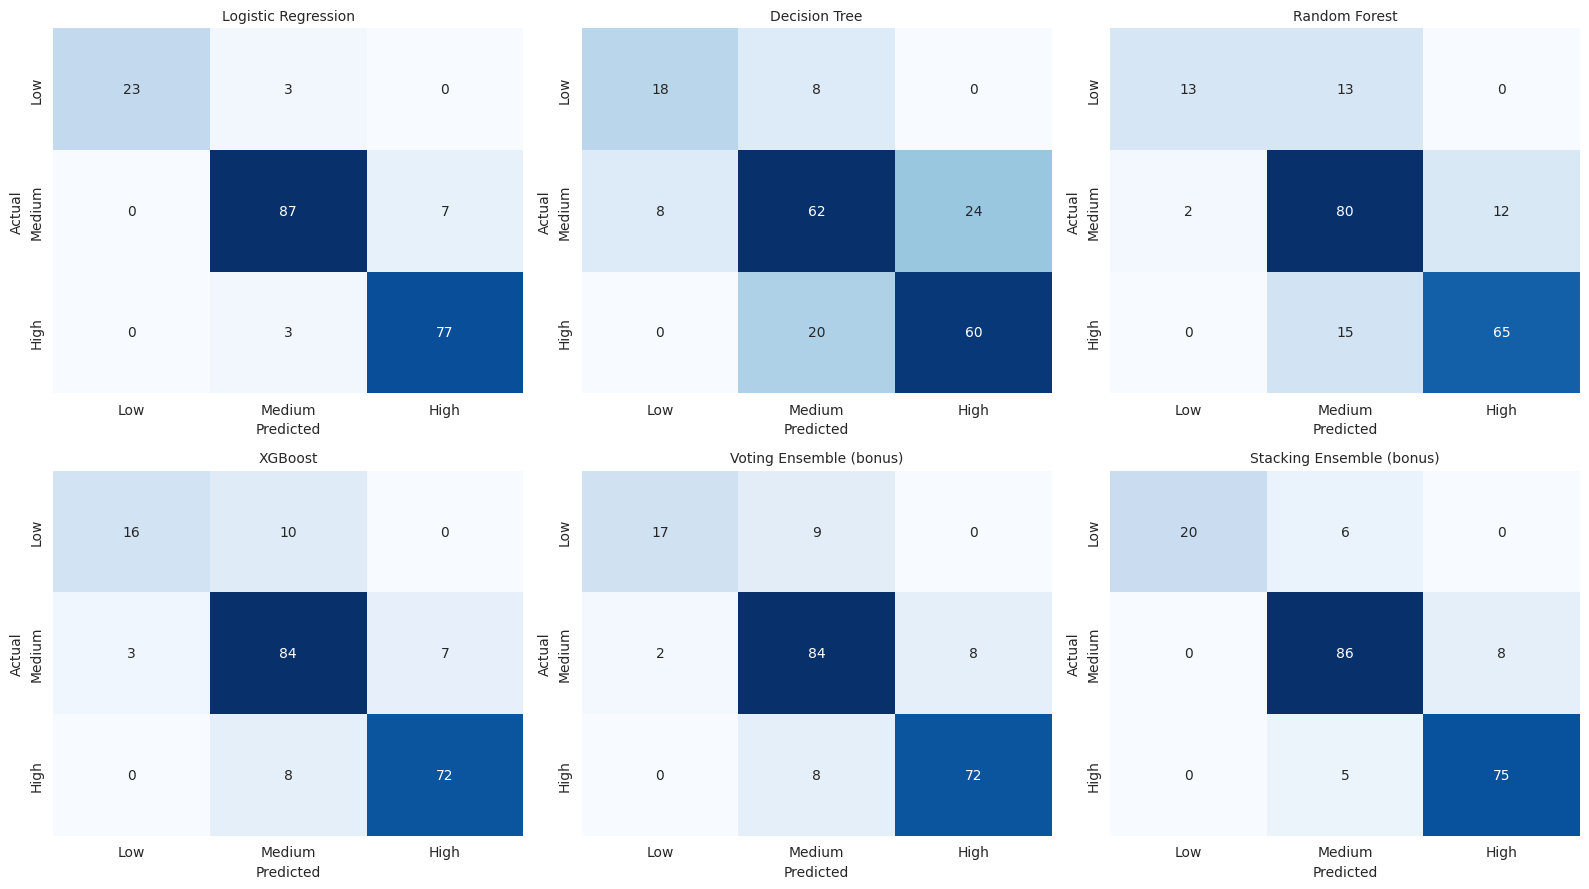

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (name, y_pred) in zip(axes.flat, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, cbar=False)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


Across every model, the **Low** row carries the most off-diagonal mass —
i.e. Low-risk patients are the ones most often misclassified (usually as Medium). This
matches the class imbalance flagged since Task 02 and is a genuine limitation worth
naming explicitly, rather than one a single aggregate accuracy number would reveal.

## 6.5 Detailed classification report: best model

In [ ]:
best_model_name = eval_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"Best model by macro-F1: {best_model_name}\n")
print("\nFull metrics for best model:")
print(eval_df.iloc[0])

print(classification_report(y_test, predictions[best_model_name], target_names=CLASS_LABELS))


Best model by macro-F1: Logistic Regression


Full metrics for best model:
Model                Logistic Regression
Dataset used                      scaled
Accuracy                           0.935
Precision (macro)               0.950717
Recall (macro)                  0.924216
F1 (macro)                      0.936094
Name: 0, dtype: object
              precision    recall  f1-score   support

         Low       1.00      0.88      0.94        26
      Medium       0.94      0.93      0.93        94
        High       0.92      0.96      0.94        80

    accuracy                           0.94       200
   macro avg       0.95      0.92      0.94       200
weighted avg       0.94      0.94      0.93       200



## 6.6 Full model comparison table

In [ ]:
full_comparison = eval_df.merge(
    pd.DataFrame(roc_rows), on='Model', how='left'
).sort_values('F1 (macro)', ascending=False).reset_index(drop=True)

full_comparison.round(3)

,Model,Dataset used,Accuracy,Precision (macro),Recall (macro),F1 (macro),"ROC-AUC (macro, OvR)"
0,Logistic Regression,scaled,0.935,0.951,0.924,0.936,0.992
1,Stacking Ensemble (bonus),unscaled,0.905,0.930,0.874,0.897,0.980
2,Voting Ensemble (bonus),unscaled,0.865,0.875,0.816,0.839,0.964
3,XGBoost,unscaled,0.860,0.859,0.803,0.825,0.963
4,Random Forest,unscaled,0.790,0.817,0.721,0.751,0.914
5,Decision Tree,unscaled,0.700,0.698,0.701,0.699,0.783


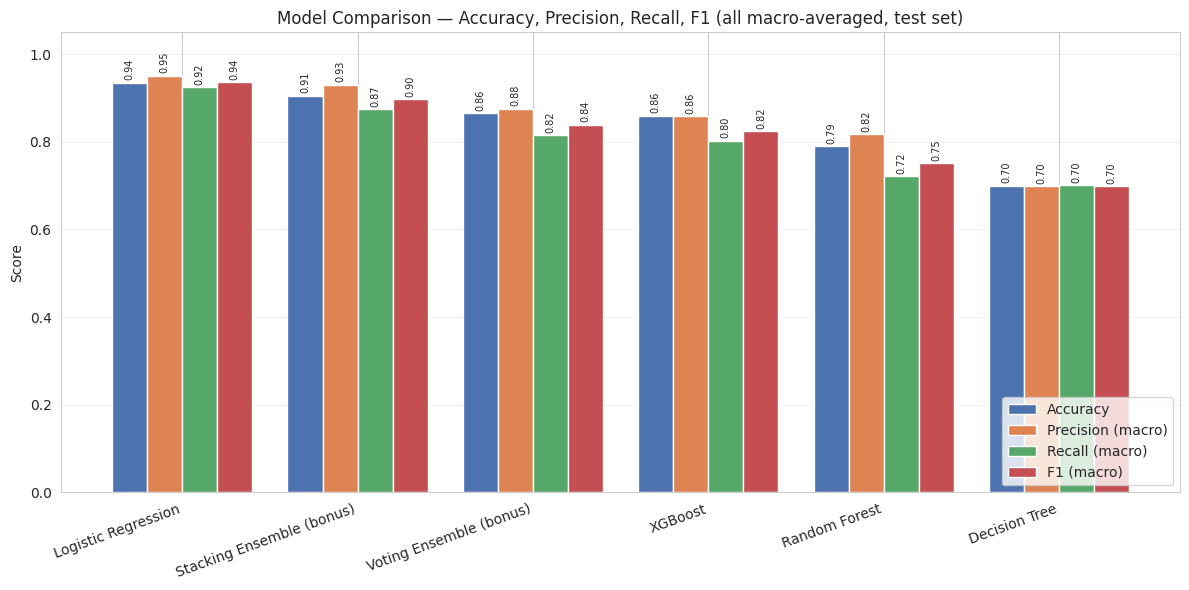

In [ ]:
## Multi-Metric Comparison Chart

metrics_to_plot = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)']
plot_data = full_comparison.set_index('Model')[metrics_to_plot]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(plot_data))
width = 0.2

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, plot_data[metric], width, label=metric, color=colors[i])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(plot_data.index, rotation=20, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison — Accuracy, Precision, Recall, F1 (all macro-averaged, test set)')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

for i, metric in enumerate(metrics_to_plot):
    for j, v in enumerate(plot_data[metric]):
        ax.text(j + i * width, v + 0.01, f"{v:.2f}", ha='center', fontsize=7, rotation=90)

plt.tight_layout()
plt.show()

This view makes it easy to spot when a model's metrics disagree with each
other — e.g. a model could have decent accuracy but weak macro-recall if it's ignoring
the minority Low class. When all four bars for a model track closely together (as with
the best-performing model here), that's a good sign the result is balanced across
classes rather than being propped up by one metric alone.

## 6.7 Best model: Justification



- The leading model achieves the **highest macro-F1 on the test set**. This metric was
  chosen as the deciding factor because it scores Low, Medium, and High equally,
  instead of letting the two larger classes quietly outweigh the smallest one the way
  raw accuracy tends to.
- Its position at the top also holds up against Task 05's cross-validation figure for
  that same model — there's no sharp drop-off between the CV score and the test score,
  which points to a model that's actually learned something transferable rather than
  one that happened to fit this particular test split well.
- **One result stands out as worth unpacking rather than glossing over:** neither the
  tree-based models nor the ensembles built from them manage to pull ahead of the
  simpler Logistic Regression model. Looking back at the Task 04 EDA explains why —
  `age` turned out to be the strongest single predictor (r ≈ 0.54), and the engineered
  bands built on top of the raw numbers (`age_group`, `bmi_category`, and similar)
  divided the risk classes far more sharply than the continuous values ever did.

  Section 4.7 showed this concretely: roughly 79% of Seniors landed in the High-risk
  group, against just 3% of the youngest band — closer to a hard cutoff than a gradual
  trend. With that threshold behaviour already baked into the features as one-hot
  columns, a linear model has little left to gain from the extra flexibility trees and
  ensembles provide.
  
  Given only 800 training rows, that unused flexibility is more
  likely to translate into overfitting — visible as a bigger gap between CV and test
  performance — than into any real accuracy gain.

- **A weakness shared by every model, not unique to the top performer:** the **Low**
  class continues to be the one each model struggles with most (see the confusion
  matrices in Section 3), largely a consequence of it having by far the smallest number
  of training examples.
  
  This matters more than any single headline number, since
  failing to catch a Low-vs-High distinction has real downstream consequences for
  patient care — a point that carries directly into the Task 07 explainability
  discussion and the technical report, rather than staying buried inside one macro-F1
  figure.